In [180]:
import numpy as np
from numpy import cos, sin, exp, pi,sqrt
import matplotlib.pyplot as plt
from matplotlib.pyplot import plot
from mpmath import pcfd
from tqdm import tqdm
import sys
sys.path.append("../../../src/")
import kblock_ising_model as kb
import kibble_zurek as kz
from time import time


In [128]:
##Calculating a single time slice

L = 100
N_taus= 75
taus = np.logspace(-3,3.,N_taus)

n_values = [2,3 ,4,5,6,7,8,9,10,11,12,13,14]
N_n = len(n_values)

# Preallocate arrays
KZ_array = np.zeros((N_n,N_taus))
GS_array = np.zeros((N_n,N_taus))
for t_i, tau in enumerate(tqdm(taus)):
    t = tau
    state_t = kz.state(L, tau, t)
    k0 = kb.k_vals(L)
    U0 = kb.U(k0, -kz.g(t, tau))

    for i, n in enumerate(n_values):
        P_kz = kz.P_n(n, state_t)
        P0 = kb.P_n(n, U0, k0)
        diff = kz.delta(state_t, [U0, k0], n)

        KZ_array[i,t_i] = P_kz
        GS_array[i,t_i] = P0




  0%|          | 0/75 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
 99%|█████████▊| 74/75 [9:50:41<02:00, 120.71s/it]    /Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:26: RuntimeWarning: invalid value encountered in scalar multiply
  return prefactor*complex(pcfd(nu,argument))
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scal

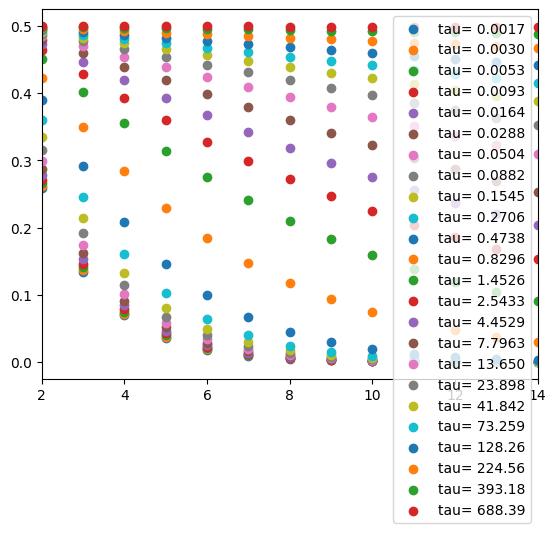

In [129]:
for i in range(3, N_taus-1,3):
    plt.scatter(
        n_values,
        (KZ_array[:, i]),
        label=f"tau= {str(taus[i])[:6]}"
    )

plt.xlim(n_values[0], n_values[-1])
plt.legend()
#plt.loglog()
#plt.yscale("log")


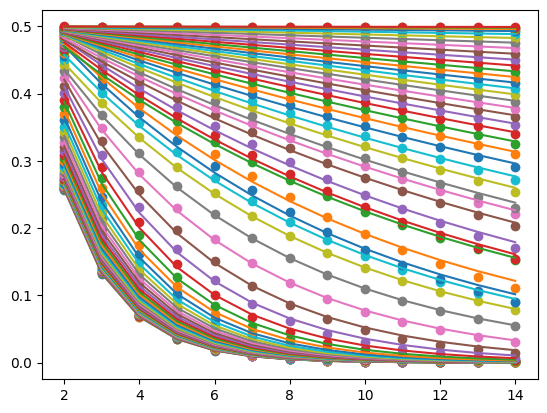

In [137]:
import numpy as np
from scipy.optimize import curve_fit
Alist= []
Blist = []
for i in range(len(taus)-1):
    # Example data
    x = np.array(n_values)
    y =KZ_array[:,i]
    def exp_model(x, A, b):
        return A * np.exp(-b * x)

    # Fit
    popt, pcov = curve_fit(exp_model, x, y, p0=(1, 1))
    A_fit, b_fit = popt
    Alist.append(A_fit)
    Blist.append(b_fit)
    plt.scatter(x,y)
    plt.plot(x,exp_model(x,A_fit,b_fit))


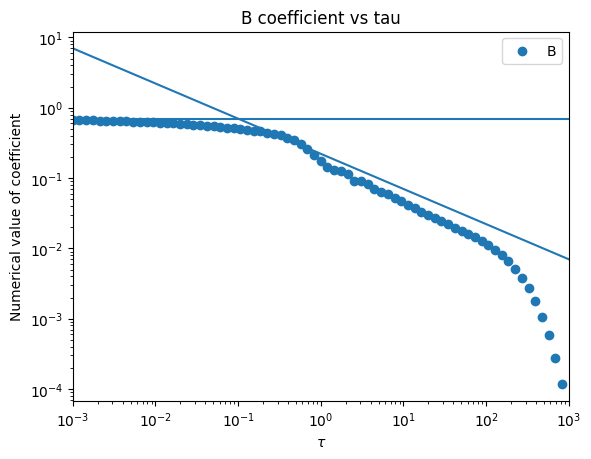

In [175]:
plt.scatter(taus[:-1],Blist,label="B")
#plt.scatter(taus[:-1],Alist,label="A")
plt.xlabel(r"$\tau$")
plt.xscale("log")
plt.ylabel("Numerical value of coefficient")
plt.hlines(np.log(2),taus[0],taus[-1])

N= 30
plt.plot(taus,(taus/taus[N])**(-1/2)*Blist[N])
plt.yscale("log")
#plt.ylim(0,0.75)
plt.xlim(taus[0],taus[-1])
plt.legend()
plt.title("B coefficient vs tau")
plt.savefig("B_coefficient_vs_tau.pdf")

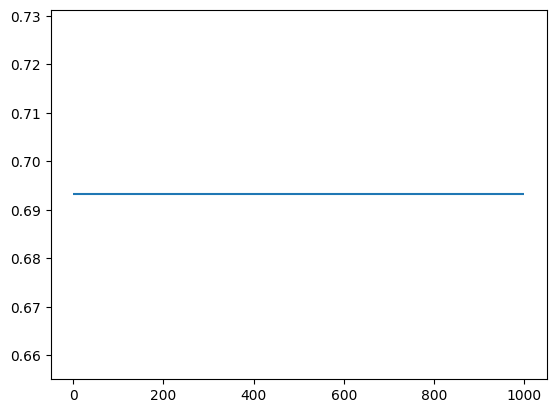

In [ ]:
npKZ_array

array([[2.57005130e-01, 2.57690289e-01, 2.58442405e-01, 2.59268004e-01,
        2.60174241e-01, 2.61168961e-01, 2.62260759e-01, 2.63459056e-01,
        2.64774164e-01, 2.66217372e-01, 2.67801028e-01, 2.69538627e-01,
        2.71444905e-01, 2.73535933e-01, 2.75829213e-01, 2.78343775e-01,
        2.81100259e-01, 2.84120997e-01, 2.87430066e-01, 2.91053315e-01,
        2.95018343e-01, 2.99354409e-01, 3.04092248e-01, 3.09263743e-01,
        3.14901405e-01, 3.21037586e-01, 3.27703307e-01, 3.34926578e-01,
        3.42730002e-01, 3.51127432e-01, 3.60119342e-01, 3.69686559e-01,
        3.79781934e-01, 3.90319661e-01, 4.01162302e-01, 4.12106552e-01,
        4.22870776e-01, 4.33091220e-01, 4.42339892e-01, 4.50184405e-01,
        4.56311904e-01, 4.60716702e-01, 4.63871580e-01, 4.66658673e-01,
        4.69793753e-01, 4.73022230e-01, 4.75488572e-01, 4.77532922e-01,
        4.79747641e-01, 4.81472269e-01, 4.83216107e-01, 4.84715905e-01,
        4.86078484e-01, 4.87332531e-01, 4.88467719e-01, 4.894950

In [177]:
##Calculating a single time slice

L = 100
N_taus= 75
taus = np.array([1])

n_values = [12,14,16]
N_n = len(n_values)

# Preallocate arrays
KZ_array = np.zeros((N_n,N_taus))
GS_array = np.zeros((N_n,N_taus))
for t_i, tau in enumerate((taus)):
    t = tau
    state_t = kz.state(L, tau, t)
    k0 = kb.k_vals(L)
  #  U0 = kb.U(k0, -kz.g(t, tau))

    for i, n in enumerate(tqdm(n_values)):
        P_kz = kz.P_n(n, state_t)
       # P0 = kb.P_n(n, U0, k0)
        diff = kz.delta(state_t, [U0, k0], n)

        KZ_array[i,t_i] = P_kz
        GS_array[i,t_i] = P0




  0%|          | 0/3 [00:00<?, ?it/s]/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kibble_zurek.py:142: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,state)
/Users/kristianmunnikhuis/Research Projects/subsystem_loschmidt_echo/scripts/Kibble_Zurek_Scaling/Kibble_Zurek_Scaling_Figures/../../../src/kblock_ising_model.py:130: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
100%|██████████| 3/3 [00:45<00:00, 15.01s/it]


In [179]:
KZ_array[:,0]

array([0.07697124, 0.05416942, 0.03811995])